# Temporal Analysis — Per-Cell Switch-Off Behaviour

Compares DQN_final, DQN-QoS-Penalty, and QR-CQL_v_final on a single micro cell across the eval week (timesteps 664-829), showing PRB load alongside each model's ON/OFF decisions. Run cells top to bottom; re-run the "pick cell" cell with a different index to try other cells without re-running everything else.

In [60]:
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt
from simulator import RANEnv
from policies import load_dqn_policy, load_qr_cql_policy

EVAL_START, EVAL_END = 664, 829

PRB_CSV = "Datasets/Base/simulator_ready_traffic_PRB.csv"
MR_CSV  = "Datasets/Base/simulator_ready_traffic_MR.csv"

# --- confirm these paths match your actual saved checkpoints ---
DQN_FINAL_PATH   = "models/dqn_final_42.zip"
DQN_QOS_PATH     = "models/dqn_penalty_42.zip"
QRCQL_FINAL_PATH = "models/qr_cql_policy_42"

## Step 1 — Pick a candidate cell

Loads your existing DQN eval results CSV (from `main.py --policy dqn --split eval`) and ranks micro cells by flip-flop count, so you can pick the most illustrative one. Change `RESULTS_CSV` if your file is named differently, and change `RANK` (0 = worst offender, 1 = second worst, etc.) to try different cells.

In [61]:
domain_map = {
    'C1': 'Rush', 'C2': 'Hospital', 'C3': 'Rush', 'C4': 'Transport', 'C5': 'Rush',
    'C6': 'Rush', 'C7': 'Rush', 'C9': 'Rush', 'C10': 'Rush', 'C11': 'House',
    'C12': 'Shop', 'C14': 'Rush', 'C15': 'Shop', 'C16': 'Rush', 'C17': 'House',
    'C18': 'Rush', 'C20': 'House', 'C21': 'House', 'C22': 'House', 'C23': 'House',
    'C24': 'House', 'C25': 'House', 'C26': 'Transport', 'C27': 'Shop', 'C28': 'House',
    'C29': 'Rush', 'C30': 'House', 'C31': 'Rush', 'C32': 'Rush', 'C34': 'Shop',
    'C35': 'House', 'C37': 'Transport', 'C38': 'Hospital', 'C39': 'Rush', 'C40': 'Rush',
    'C41': 'Rush', 'C42': 'Rush', 'C43': 'Shop', 'C45': 'House',
    'M1': 'Rush', 'M2': 'Rush', 'M3': 'Transport', 'M4': 'House', 'M5': 'House',
    'M6': 'Shop', 'M7': 'Rush',
}

# pick the archetype you want to inspect
TARGET_TYPE = "Rush"   # or "Rush"

candidates = [cid for cid, t in domain_map.items() if t == TARGET_TYPE]
print(f"{TARGET_TYPE} cells available: {candidates}")



Rush cells available: ['C1', 'C3', 'C5', 'C6', 'C7', 'C9', 'C10', 'C14', 'C16', 'C18', 'C29', 'C31', 'C32', 'C39', 'C40', 'C41', 'C42', 'M1', 'M2', 'M7']


In [ ]:
# manually set which one you want to look at, from the printed list above
MANUAL_CELL_ID = "C1"   # <-- change this to whichever candidate you want

# convert cell ID -> micro_pos (position in the 39-length micro array)
env_tmp = RANEnv(prb_csv=PRB_CSV, mr_csv=MR_CSV, start=EVAL_START, end=EVAL_END)
cell_idx_tmp = env_tmp.cell_ids.index(MANUAL_CELL_ID)
TARGET_MICRO_POS = env_tmp.micro_pos[cell_idx_tmp]

print(f"{MANUAL_CELL_ID} -> micro_pos={TARGET_MICRO_POS}")

RANEnv ready — 166 timesteps (7 macros, 39 micros)
C10 -> micro_pos=8


## Step 2 — Run all three models on the eval split, logging the chosen cell's trace

In [63]:
def run_and_log(policy_type, path, target_pos):
    env = RANEnv(
        prb_csv=PRB_CSV,
        mr_csv=MR_CSV,
        start=EVAL_START,
        end=EVAL_END,
        is_continuous_proxy=False,
    )
    if policy_type == "dqn":
        policy_fn = load_dqn_policy(path)
    else:
        policy_fn = load_qr_cql_policy(path)

    cell_idx = env.micro_indices[target_pos]
    cell_id  = env.cell_ids[cell_idx]

    obs, _ = env.reset()
    records = []
    done = False
    while not done:
        t = env.t
        prb_now = float(env.prb[t, cell_idx])
        action = policy_fn(obs, env)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        on_status = int(info["action"][target_pos])
        records.append({"t": t, "prb_load": prb_now, "on_status": on_status})

    return cell_id, pd.DataFrame(records)

MODELS = {
    "DQN_final":       ("dqn", DQN_FINAL_PATH),
    "DQN-QoS-Penalty": ("dqn", DQN_QOS_PATH),
    "QR-CQL_v_final":  ("qr_cql", QRCQL_FINAL_PATH),
}

all_traces = {}
cell_id_used = None
for name, (ptype, path) in MODELS.items():
    cell_id_used, trace_df = run_and_log(ptype, path, TARGET_MICRO_POS)
    all_traces[name] = trace_df
    print(f"{name}: {trace_df['on_status'].sum()} / {len(trace_df)} timesteps ON")

print(f"\nCell used: {cell_id_used} (micro_pos={TARGET_MICRO_POS})")

RANEnv ready — 166 timesteps (7 macros, 39 micros)
DQN policy loaded from models/dqn_final_42.zip
DQN_final: 109 / 166 timesteps ON
RANEnv ready — 166 timesteps (7 macros, 39 micros)
DQN policy loaded from models/dqn_penalty_42.zip
DQN-QoS-Penalty: 109 / 166 timesteps ON
RANEnv ready — 166 timesteps (7 macros, 39 micros)
QR-CQL policy loaded from models/qr_cql_policy_42
QR-CQL_v_final: 110 / 166 timesteps ON

Cell used: C10 (micro_pos=8)


## Step 3 — Plot: PRB load with ON/OFF shading, one subplot per model

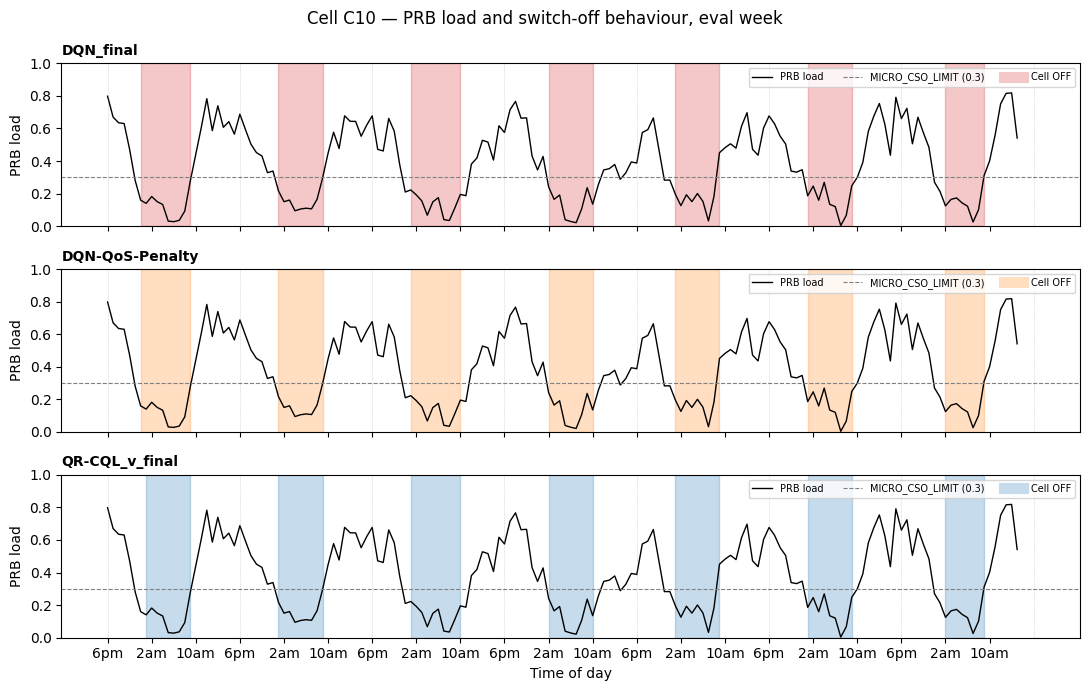

In [64]:
SHIFT_HOURS = 0   # your manual value
fig, axes = plt.subplots(len(all_traces), 1, figsize=(11, 7), sharex=True)
colors = {"DQN_final": "#d62728", "DQN-QoS-Penalty": "#ff7f0e", "QR-CQL_v_final": "#1f77b4"}

def off_intervals(on_status_array):
    intervals = []
    in_off = False
    start = None
    for i, status in enumerate(on_status_array):
        if status == 0 and not in_off:
            start = i
            in_off = True
        elif status == 1 and in_off:
            intervals.append((start, i))
            in_off = False
    if in_off:
        intervals.append((start, len(on_status_array)))
    return intervals

for ax, (name, trace_df) in zip(axes, all_traces.items()):
    x = trace_df["t"].values - trace_df["t"].values[0] + SHIFT_HOURS
    ax.plot(x, trace_df["prb_load"], color="black", linewidth=1.0, label="PRB load")
    on_status = trace_df["on_status"].values
    for start, end in off_intervals(on_status):
        ax.axvspan(x[start], x[min(end, len(x) - 1)], color=colors.get(name, "gray"), alpha=0.25)
    ax.axhline(0.3, color="gray", linestyle="--", linewidth=0.8, label="MICRO_CSO_LIMIT (0.3)")
    for d in np.arange(SHIFT_HOURS, x.max() + 24, 24):
        ax.axvline(d, color="gray", linestyle=":", linewidth=0.5, alpha=0.5)
    ax.set_ylim(0, 1)
    ax.set_ylabel("PRB load")
    ax.set_title(name, loc="left", fontsize=10, fontweight="bold")
    ax.plot([], [], color=colors.get(name, "gray"), alpha=0.25, linewidth=8, label="Cell OFF")
    ax.legend(loc="upper right", fontsize=7, ncol=3)

# ticks every 8 hours starting at the first data point, cycling through the 3 labels
time_labels = ["6pm", "2am", "10am"]
tick_positions = np.arange(SHIFT_HOURS, x.max() + 1, 8)
tick_labels = [time_labels[i % 3] for i in range(len(tick_positions))]

axes[-1].set_xlabel("Time of day")
axes[-1].set_xticks(tick_positions)
axes[-1].set_xticklabels(tick_labels)

fig.suptitle(f"Cell {cell_id_used} — PRB load and switch-off behaviour, eval week", fontsize=12)
fig.tight_layout()
plt.savefig("results/temporal_analysis.png", dpi=200, bbox_inches="tight")
plt.show()